In [1]:
# Data Analysis Project - Titanic
# Objective: Explore dataset, find insights, build simple model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Cleaning Plan

- **Columns to drop**
  - PassengerId → irrelevant unique identifier, no predictive value.
  - Name → too granular, not useful for modeling.
  - Ticket → messy string, not standardized.
  - Cabin → mostly missing, unreliable.

- **Handling missing values**
  - Age → impute with median (robust to outliers).
  - Embarked → impute with mode (most common port).
  - Cabin → drop column entirely (too sparse).

- **Type conversions**
  - Sex → convert to categorical (male/female).
  - Embarked → convert to categorical (C/Q/S).
  - Survived → keep as integer (target variable).


In [3]:
# Example: drop PassengerId
df = df.drop(columns=["PassengerId"])

# Convert categorical to category type
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")


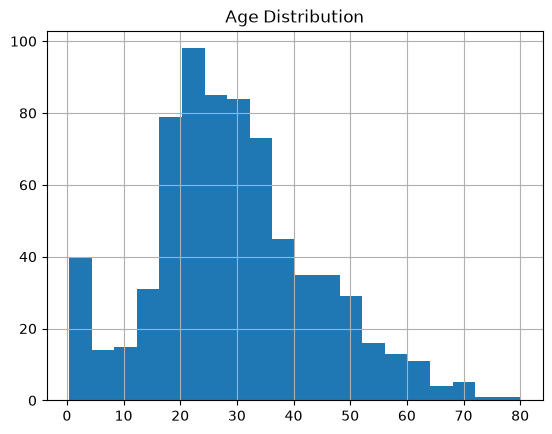

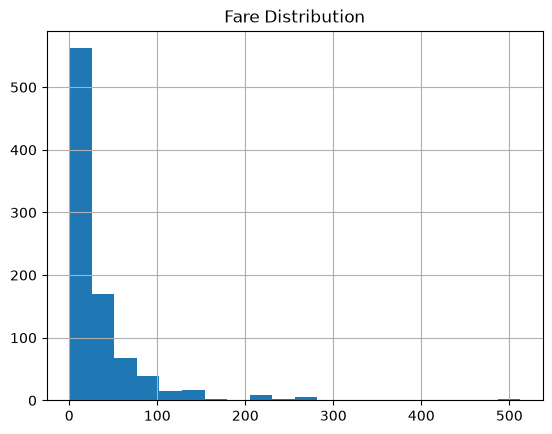

In [4]:
df["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.show()

df["Fare"].hist(bins=20)
plt.title("Fare Distribution")
plt.show()


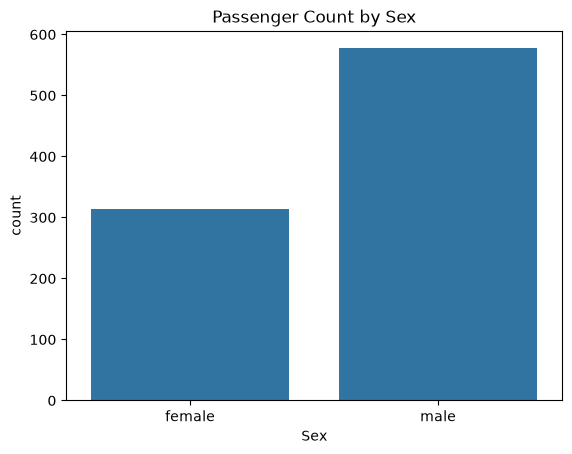

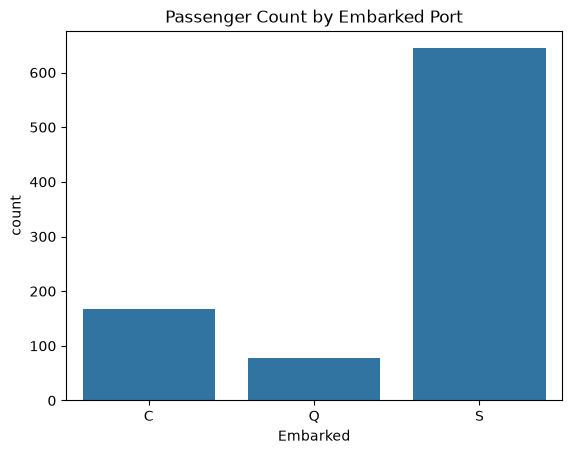

In [5]:
sns.countplot(x="Sex", data=df)
plt.title("Passenger Count by Sex")
plt.show()

sns.countplot(x="Embarked", data=df)
plt.title("Passenger Count by Embarked Port")
plt.show()


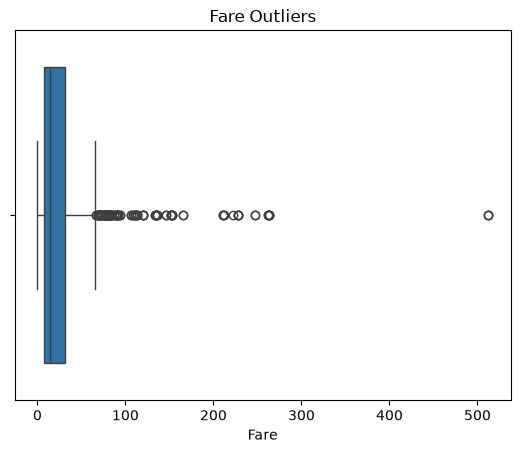

In [6]:
sns.boxplot(x=df["Fare"])
plt.title("Fare Outliers")
plt.show()


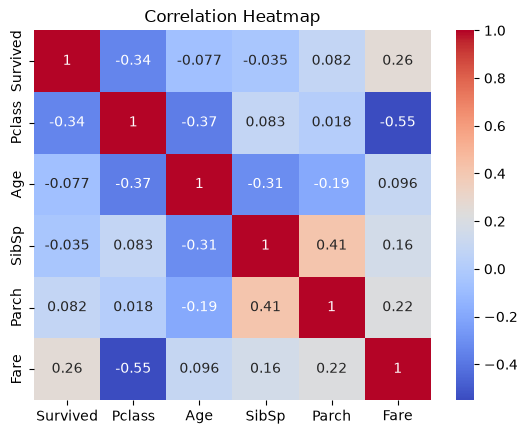

In [7]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Check missing values again:

In [8]:
df.isnull().sum()


Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Handle Age (numeric, missing) → impute with median:

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

Handle Embarked (categorical, missing) → impute with mode:

In [10]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Handle Cabin (mostly missing) → drop column:

In [11]:
df = df.drop(columns=["Cabin"])


Verify Cleaning

In [12]:
df.isnull().sum()


Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

Encode categorical variables

In [13]:
# Convert Sex to numeric
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)


Create new features

In [14]:
# Family size = SibSp + Parch + 1 (self)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# IsAlone = 1 if FamilySize == 1 else 0
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


Scale numeric features

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])


Verify

In [16]:
df.head()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",0,-0.565736,1,0,A/5 21171,-0.502445,False,True,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0.663861,1,0,PC 17599,0.786845,False,False,2,0
2,1,3,"Heikkinen, Miss. Laina",1,-0.258337,0,0,STON/O2. 3101282,-0.488854,False,True,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0.433312,1,0,113803,0.420730,False,True,2,0
4,0,3,"Allen, Mr. William Henry",0,0.433312,0,0,373450,-0.486337,False,True,1,1


In [17]:
df = df.drop(columns=["Name", "Ticket", "Cabin"], errors="ignore")

In [18]:
if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
    df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [19]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [20]:
if "Embarked_Q" in df.columns:
    df["Embarked_Q"] = df["Embarked_Q"].astype(int)
if "Embarked_S" in df.columns:
    df["Embarked_S"] = df["Embarked_S"].astype(int)

In [21]:
print(df.dtypes)          # should show int64/float64 only

Survived         int64
Pclass           int64
Sex           category
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
FamilySize       int64
IsAlone          int64
dtype: object


In [22]:
print(df.isnull().sum())  # should all be zero

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
FamilySize    0
IsAlone       0
dtype: int64


In [23]:
df.to_csv("../data/titanic_clean.csv", index=False)